# <br>

<img src="logo_UNSAM.jpg" align="right" width="180" /> 

<br><br><br>

<h3 align="center">Análisis y Procesamiento de Señales</h3>

<h1 align="center"><b>TS1: Síntesis y operaciones de señales</b></h1>
<h3 align="center">Paloma Ribnikar Diaz</h3>


## Objetivos
El objetivo del trabajo visualizar el módulo de la *transformada de Fourier* de las siguientes señales sinusoidales y secuencias aleatorias de ruido sintetizadas a continuación:
   * **Señal sinusoidal:** $f = 2 \text{ kHz}$ con al menos 10 puntos por período.
   * **Señal sinusoidal modificada:** Potencia media $P = 2 \text{ W}$ y desfasaje $\phi = \frac{\pi}{2}$.
   * **Ruido Gaussiano (Normal):** Secuencia aleatoria de ruido normalmente distribuido con DC de 0V y varianza $\sigma^2 = 0.1\text{ W}$.
   * **Ruido Uniforme:** Secuencia aleatoria de ruido uniformemente distribuido con DC de 0V y $\sigma^2 = 0.1\text{ W}$. 
   * **Pulso rectangular (cuadrada):** $f = 2 \text{ kHz}$, potencia $P = 1 \text{ W}$ y ciclo de actividad del 50%.


## Introducción
### Base teórica
$\quad$ En un primer lugar, tomando como base la **TS0: "Primeros pasos en la simulación"**, la señal sinusoidal de la que se parte para poder sintetizar lo pedido tuvo que ser discretizada (muestreada). Tal como vimos en dicho trabajo, la consecuencia matemática de discretizar el tiempo es que el espectro de frecuencia se periodiza (generando réplicas cada múltiplos de la frecuencia de muestreo ${f_s}$). Por ende, para evitar el solapamiento de las réplicas espectrales (fenómeno de *aliasing*), se busca cumplir el **Teorema de Nyquist-Shannon**, el cual establece que la frecuencia de muestreo ${f_s}$ debe ser estrictamente mayor al doble del ancho de banda máximo (${f_b}$) de la señal analógica:
$$f_s > 2f_b$$
$$f_{\text{Nyquist}} = \frac{f_s}{2} > f_b $$

### Transformada de Fourier
$\quad$ Si nuestro objetivo es pasar del dominio temporal al frecuencial, al aplicar **Transformada de Fourier de Tiempo Discreto (DTFT)** esta devuelve un espectro continuo que requeriría infinitos puntos y por ende, una memoria infinita donde ser almacenados.
Con el objetivo de resolver esta limitación computacional, es necesario discretizar también el eje de frecuencias. Esta operación da origen a la **Transformada Discreta de Fourier (DFT)**, la cual toma únicamente N muestras equiespaciadas del espectro (de 0 a f_s).
Esta división del espectro genera una grilla de canales de frecuencia que denominamos **"Bins"**, donde la distancia entre cada casillero define nuestra resolución espectral ($\Delta f$):
$$\Delta f = \frac{f_s}{N}$$

### Simetría del espectro y banda útil (Nyquist)
$\quad$ Al aplicar la DFT sobre una secuencia discreta en el tiempo y de valores reales, el algoritmos de la FFT devuelve un vector de N puntos que cubre el rango completo de frecuencias de 0 a ${f_s}$. Sin embargo, debido a la **Simetría Hermítica (o conjugada)** que poseen los espectros de las señales reales, la mitad superior de este vector (desde $\frac{f_s}{2}$ hasta $f_s$) resulta redundante, puesto a que es un "espejo" conjugado de la mitad inferior.
Es por ello que, en primer lugar, la **frecuencia de Nyquist** funciona como frontera de la banda digital útil y, en segundo lugar, para evitar la visualizacion de esta redundancia espectrar el los gráficos presentados en el informe se haya realizado un recorte (*slicing*) de los vectores, quedándonos así con la primera mitad de los bins correspondientes a las frecuencias positivas (de 0 a ${f_s}$).

### Potencia Media vs. Energía Total
$\quad$ En este caso trabajamos con señales de duración infinita y periódica, por lo que presenta energía infinita. Por lo tanto, no resulta físicamente útil analizarlo bajo el concepto de Energía total. En su lugar, se recurre a la potencia promedio, la cual cuantifica la energía transmitida por unidad de tiempo promediada en un período de la señal (N muestras)Ñ
$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2$$

### Teorema de Parseval
$\quad$ Este teorema establece que la energía (o potencia) de una señal es idéntica tanto si se calcula en el dominio del tiempo como en el de frecuencia, permitiendo así verificar que la potencia calculada a partir de las muestras temporales coincide exactamente con la suma de la energía distribuida en cada uno de los casilleros del espectro de frecuencia (FFT):

$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2} \sum_{k=0}^{N-1} |X[k]|^2$$

### Señales de Pulsos y el Ciclo de Actividad (Duty Cycle)

$\quad$ A diferencia de un tono puro, las señales cuadradas poseen transiciones abruptas que distribuyen su potencia en infinitos armónicos. Sus formas se encuentran definidas por el ciclo de actividad (o *duty cycle*, $D$), es decir, la proporción de tiempo que la señal pasa en su estado alto/activo ($\tau$) frente al estado bajo dentro de un mismo período ($T$):

$$D = \frac{\tau}{T} \cdot 100\%$$

$\quad$ En el caso de una señal cuadrada simétrica ($50\%$ de ciclo de actividad), el caso de análisis en este informe, la onda presenta simetría de media onda en el tiempo. Esta simetría hace que se anulen los armónicos pares del espectro, haciendo que la energía se concentre únicamente en un "peine" de frecuencias impares ($f_0, 3f_0, 5f_0, \dots$).

## Desarrollo y Análisis

## Código en Python

### Librerías y Definiciones

In [92]:
# -*- coding: utf-8 -*-
"""
Created on Sun Aug 30 17:36:34 2026

@author: ribni
"""
#%% LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt

import scipy.signal as sig

#%% DEFINICIONES

# Parámetros del ADC
N = 1000 # Cantidad de muestras
fs = 20000 # Frecuencia de muestreo, 20KHz

# Parámetros de la función sinusoidal
ff = 2000 # Frecuencia de la señal analógica

# vmax = np.sqrt (2)  # Amplitud pico (volts)
dc = 0  # Valor medio / offset (volts)
ph = 0  # Fase inicial (rad)

### Funciones

$\quad$ En este apartado defino, en adición a la función senoidal base de la forma $x(t) = V_{\max} \cdot \sin(2\pi \cdot f \cdot t + \phi) + DC$ empleada en la TS0, las secuencias aleatorias de ruido tanto Normal como Uniforme. Para esto último, debido a que se trata de procesos estocásticos, por lo que no existe una fórmula que describa su comportamiento, se describen de forma estadística diciendo cómo se distribuyen las probabilidades de sus valores en el espacio.
En la **secuencia normal**, la mayoría de los valores se concentran cerca de la media, y, a medida que nos alejamos hacia valores más altos/bajos la probabilidad de que aparezcan disminuye drásticamente.

$\quad$ Dado que el ruido generado por el ADC o por simulación es de **media nula ($\mu = 0$)**:
$$\sigma^2 = E\{n^2[n]\} - 0^2 \implies \sigma^2 = P_n$$

$\quad$ Por lo tanto, para que la varianza resulte de 0.1 W, despejamos de la ecuacion anterior la desviación estándar, parametro necesario para emplear la función de la libreria NumPy y definir esta secuencia:
$$\sigma^2 = 0.1$$
$$\sigma = \sqrt{0.1} \approx 0.316 \text{ V}$$

$\quad$ En la **secuencia uniforme**, la probabilidad dentro del intervalo es la misma, mientras que fuera de este resulta "imposible". La varianza de la distribución uniforme se define siempre como
$$\sigma_e^2 = \frac{(b - a)^2}{12}$$

$\quad$ Por ende, si queremos lograr una potencia promedio de $P_n = \sigma_e^2 = 0.1 \text{ W}$, despejamos el límite de amplitud máxima ($A$) en el tiempo:

$$0.1 = \frac{(2A)^2}{12} \implies 1.2 = 4A^2 \implies A = \sqrt{0.3} \approx \pm 0.547 \text{ V}$$

$\quad$ El **DC** para ambas secuencias es nulo, lo cual lo podemos interpretar como "justo e insesgado", es decir, perturba hacia arriba (valores positivos) y hacia abajo (negativos) con la misma probabilidad.

In [93]:
#%% FUNCIONES

''' Defino la Funcion señal senoidal '''
def mi_funcion_sen(vmax = np.sqrt (2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    # Rango de 0 a N-1 --> tiempo discretoo
    tt =  (np.arange (nn) / fs) #np.arange para generar un vector de N nros
    
    # Señal Senoidal
    xx = vmax * np.sin (2 * np.pi * (ff * tt) + ph) + dc
    
    return tt, xx

''' Defino la secuencia aleatoria de ruido Gaussiano con media 0 y la varianza especificada '''
def generar_ruido_gaussiano(varianza=0.1, loc=0.0, size=1000):

    # Calculo la desv. estandar (sigma) haciendo la raiz de la varianza de entrada
    sigma_nq = np.sqrt(varianza)
    
    # Genero el vector de ruido con la distribucion normal (Gaussiana)
    n_q = np.random.normal(loc=loc, scale=sigma_nq, size=size)
    
    return n_q

''' Defino la secuencia aleatoria de ruido Uniforme con media 0 y var. especif.'''
def generar_ruido_uniforme(varianza=0.1, loc=0.0, size=1000):
    
    # Para ruido uniforme, los límites dependen de la raíz de (3 * varianza)
    límite_A = np.sqrt(3 * varianza)

    # Genero el vector de ruido con distribución uniforme entre -A y A
    n_q = np.random.uniform(low=-límite_A, high=límite_A, size=size)
    
    return n_q


### Script

In [94]:
# Llamada de la funcion:
    # tt, xx = mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

# Eje de frecuencia genérico para todas las FFT
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2] # Solo tomo los valores positivos (simetrico)

<h4><font color='#666B88'> Señal sinusoidal $f = 2 \text{ kHz}$ con al menos 10 puntos por período </font></h4>

$\quad$ El período de la señal analógica sinusoidal de frecuencia $f_0 = 2 \text{ kHz}$ (que realiza $2000$ ciclos completos en un segundo) resulta en:

$$T_0 = \frac{1}{f_0} = \frac{1}{2000 \text{ Hz}} = 0.5 \text{ ms}$$

$\quad$ Para lograr garantizar **al menos 10 puntos por período**, se requiere que el período analógico $T_0$ sea como mínimo 10 veces mayor que el período de muestreo $T_s$ (la distancia temporal entre muestra y muestra):

$$T_0 \ge 10 \cdot T_s$$

$\quad$ Traduciendo esta relación al dominio de la frecuencia ($T_0 = \frac{1}{f_0}$ y $T_s = \frac{1}{f_s}$):

$$\frac{1}{f_0} \ge 10 \cdot \frac{1}{f_s} \implies f_s \ge 10 \cdot f_0$$

$\quad$ Esto significa que la **frecuencia de muestreo ($f_s$)** debe ser como mínimo 10 veces superior a la frecuencia de la señal analógica ($f_0$):

$$f_s \ge 10 \cdot (2 \text{ kHz}) \implies f_s \ge 20 \text{ kHz}$$

In [95]:
#%% INCISO 1

tt, xx1 = mi_funcion_sen(vmax = 1, dc = 0, ff = ff, ph=0, nn = N, fs = fs)   

# <================= FFT =================>
salida1 = np.fft.fft(xx1)[:N//2] / N
salida1_abs = np.absolute(salida1)
salida1_dB = 10 * np.log10(2 * (salida1_abs**2) + 1e-12)

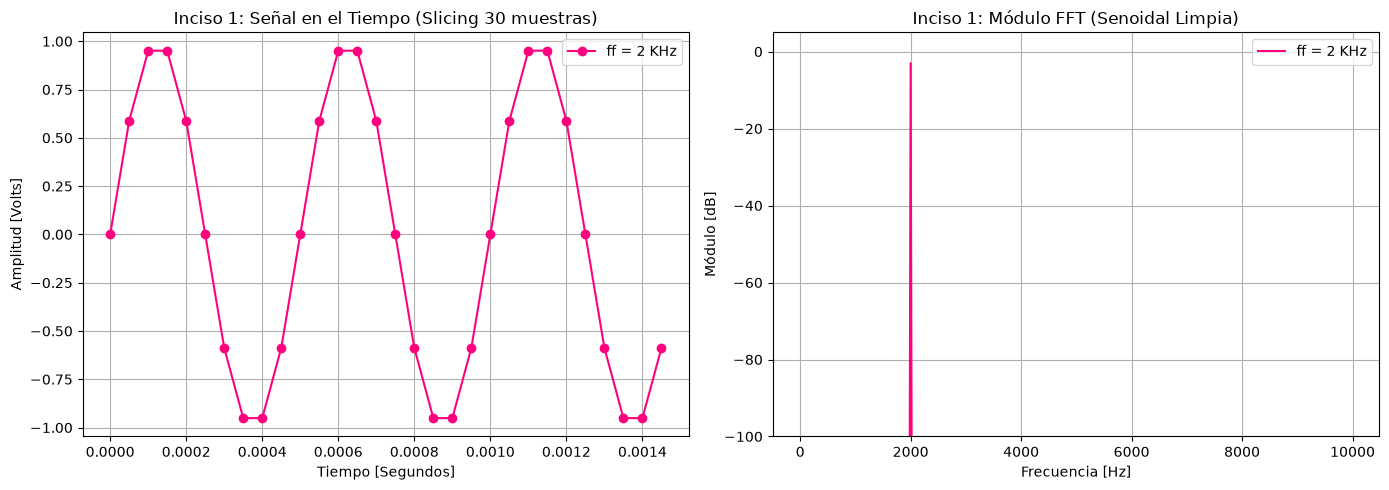

In [96]:
#%% COMPARACIÓN AMBOS GRÁFICOS
plt.figure(figsize=(14, 5)) # Una sola figura para ambos gráficos

# Gráfico izq.: tiempo (slicing 30 muestras)
plt.subplot(1, 2, 1)
plt.plot(tt[:30], xx1[:30], '-o', label='ff = 2 KHz', color='#FF007F')
plt.title('Inciso 1: Señal en el Tiempo (Slicing 30 muestras)')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)

# Gráfico der: frec. y fft
plt.subplot(1, 2, 2)
plt.plot(ff_vector_pos, salida1_dB, label='ff = 2 KHz', color='#FF007F')
plt.title('Inciso 1: Módulo FFT (Senoidal Limpia)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 5)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # para que no se superpongan las etiquetas
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ En el dominio temporal (izquierda) se aprecian las muestras discretas obtenidas (versión recortada). Mientras que en el dominio frecuencial (derecha) se evidencia un único pico (Delta de Kronecker) clavado de forma exacta en la freciemcoa fundamental de 2kHz. Debido a que la frecuencia de la señal coincide con un múltiplo entero de la resolución espectral ($\Delta f = f_s / N = 100 \text{ Hz/bin}$), la señal se encuentra perfectamente sincronicada en la grilla, provocando que toda su energía se concentre en un único casillero espectral, validando así la ausencia de **Spectral Leakage**.

<h4><font color='#a2302c'> Señal sinusoidal $f = 2010 \text{ Hz}$ --> presencia de <b>Spectral Leakage</b></font></h4>

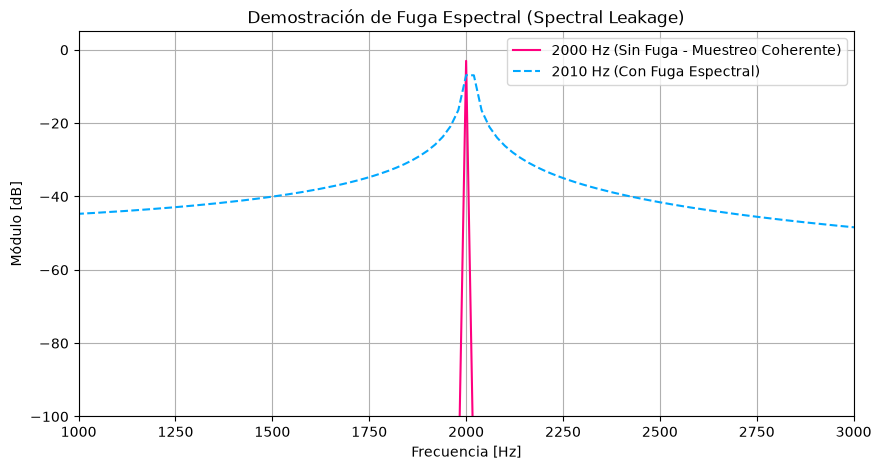

In [97]:
#%% DEMOSTRACIÓN DE FUGA ESPECTRAL (SPECTRAL LEAKAGE)
# 2. Senoidal CON fuga (f0 = 2010 Hz -> Bin 100.5)
tt, xx_con_fuga = mi_funcion_sen(vmax=1, dc=0, ff=2010, ph=0, nn=N, fs=fs)
salida_con = np.fft.fft(xx_con_fuga)[:N//2] / N
salida_con_dB = 10 * np.log10(2 * (np.abs(salida_con)**2) + 1e-12)

# Gráfico comparativo de FFT
plt.figure(figsize=(10, 5))
plt.plot(ff_vector_pos, salida1_dB, label='2000 Hz (Sin Fuga - Muestreo Coherente)', color='#FF007F', linewidth=1.5)
plt.plot(ff_vector_pos, salida_con_dB, label='2010 Hz (Con Fuga Espectral)', color='#00A8FF', linestyle='--')

plt.title('Demostración de Fuga Espectral (Spectral Leakage)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 5)
plt.xlim(1000, 3000) # Zoom entre 1 kHz y 3 kHz para apreciar bien la pollerita
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ En este caso, frecuencia de la señal **NO** coincide con un múltiplo entero de la resolución espectral ($\Delta f = f_s / N = 100.5 \text{ Hz/bin}$), dejando en evidencia el fenómeno explicado previamente en el cual la energía se "derrama" hacia los costandos, provocando que el delta se ensanche y parezca una montaña.


<h4><font color='#666B88'> Señal sinusoidal modificada: $P = 2 \text{ W}$ y $\phi = \frac{\pi}{2}$. </font></h4>

In [98]:
#%% INCISO 2
tt, xx2 = mi_funcion_sen(vmax = 2, dc = 0, ff = ff, ph=(np.pi)/2, nn = N, fs = fs)   

# FFT
salida2 = np.fft.fft(xx2)[:N//2] / N
salida2_abs = np.absolute(salida2)
salida2_dB = 10 * np.log10(2 * (salida2_abs**2) + 1e-12)

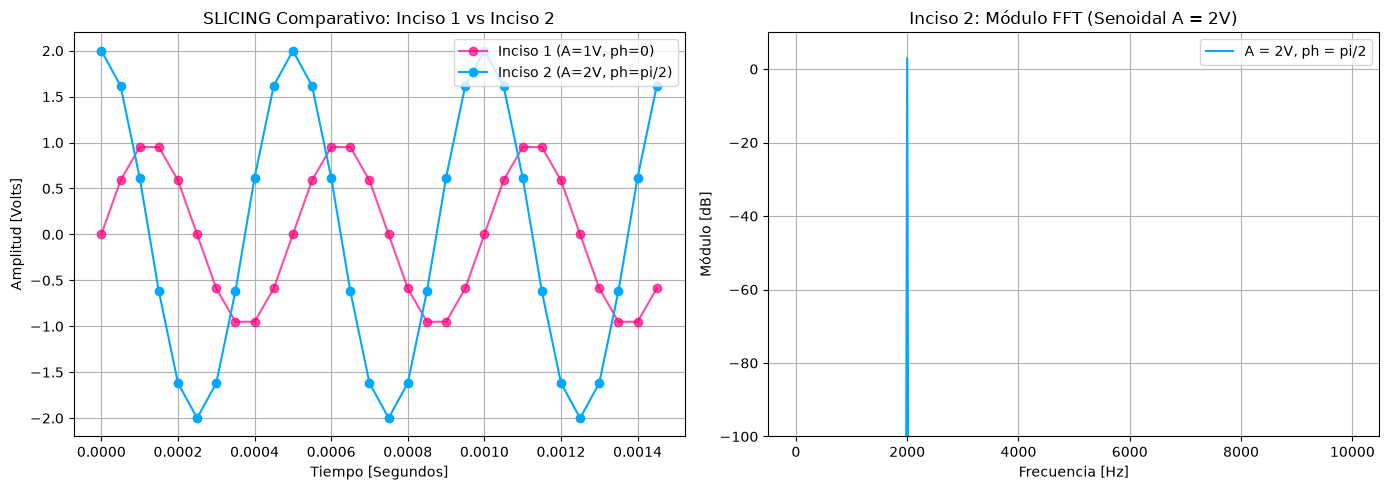

In [99]:
plt.figure(figsize=(14, 5))

# Gráfico izq.: slicing comparativo Inciso 1 vs Inciso 2
plt.subplot(1, 2, 1)
plt.plot(tt[:30], xx1[:30], '-o', label='Inciso 1 (A=1V, ph=0)', color='#FF007F', alpha=0.7)
plt.plot(tt[:30], xx2[:30], '-o', label='Inciso 2 (A=2V, ph=pi/2)', color='#00A8FF')
plt.title('SLICING Comparativo: Inciso 1 vs Inciso 2')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)

# Gráfico der.: frecuencia (FFT Inciso 2)
plt.subplot(1, 2, 2)
plt.plot(ff_vector_pos, salida2_dB, label='A = 2V, ph = pi/2', color='#00A8FF') 
plt.title('Inciso 2: Módulo FFT (Senoidal A = 2V)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 10) # Limita el eje Y entre -100 y 10 dB
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ En el gráfico temporal (izquierda) se contrasta la señal senoidal base (Inciso 1) con una de amplitud duplicada y desfasaje inicial de $\phi = \frac{\pi}{2}$. El incremento de su amplitud pico a $V_{\max} = 2 \text{ V}$ busca satisfacer la condición de potencia media asignada de $P = 2 \text{ W}$.
Para una señal senoidal pura de amplitud $V_{\max}$, la potencia media $P$ (sobre una carga de $1\,\Omega$) se calcula como:
$$P = \frac{V_{\max}^2}{2}$$
Sustituyendo la amplitud $V_{\max} = 2 \text{ V}$:
$$P = \frac{2^2}{2} = \frac{4}{2} = 2 \text{ W}$$

$\quad$ En frecuencia (derecha), el espectro mantiene su pico centrado en la componente fundamental de $2 \text{ kHz}$, pero la potencia de la delta se incrementa proporcionalmente debido al aumento de amplitud en el tiempo, cumpliendo de esta forma con el **Teorema de Parseval de conservación de la energía**. Se decidió omitir la comparación entre ambos incisos para el módulo de la FFT ya que gráficamente en dB resulta imperceptible (solo difieren en 6dB).

<h4><font color='#666B88'> Ruido Gaussiano (Normal): DC de 0V y  $\sigma^2 = 0.1\text{ W}$. </font></h4>

In [100]:
#%% INCISO 3
n_q_g = generar_ruido_gaussiano(varianza=0.1, loc=0.0, size=N) 
xx_ruidosa_g = xx1 + n_q_g

# <================= FFT =================>
salida_g_dB = 10 * np.log10(2 * (np.abs(np.fft.fft(xx_ruidosa_g)[:N//2] / N)**2) + 1e-12)

<h4><font color='#666B88'> Ruido Uniforme: DC de 0V y  $\sigma^2 = 0.1\text{ W}$. </font></h4>

In [101]:
#%% INCISO 4
n_q_u = generar_ruido_uniforme(varianza=0.1, loc=0.0, size=N) 
xx_ruidosa_u = xx1 + n_q_u

# <================= FFT =================>
salida_u_dB = 10 * np.log10(2 * (np.abs(np.fft.fft(xx_ruidosa_u)[:N//2] / N)**2) + 1e-12)

<h4><font color='#666B88'> GRAFICOS COMPARATIVOS </font></h4>

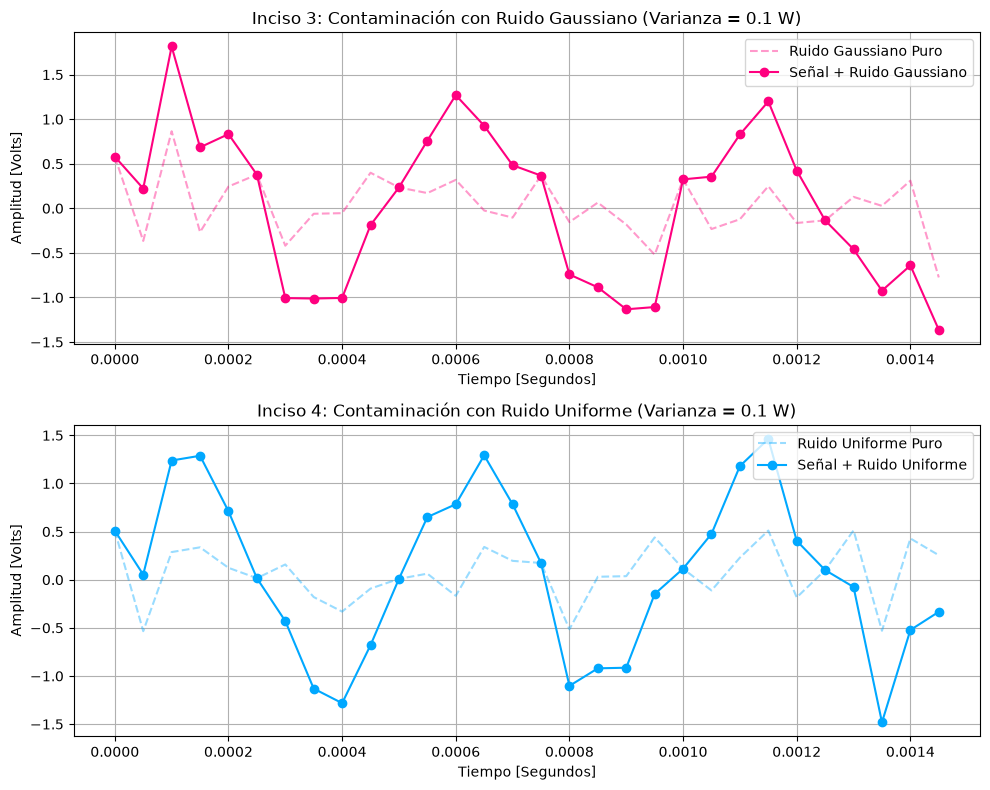

In [102]:
#%% COMPARACIÓN: RUIDO GAUSSIANO (INCISO 3) VS RUIDO UNIFORME (INCISO 4)

plt.figure(figsize=(10, 8))

# Arriba: Ruido Gaussiano
plt.subplot(2, 1, 1)
plt.plot(tt[:30], n_q_g[:30], label='Ruido Gaussiano Puro', color='#FF007F', alpha=0.4, linestyle='--')
plt.plot(tt[:30], xx_ruidosa_g[:30], '-o', label='Señal + Ruido Gaussiano', color='#FF007F', linewidth=1.5)
plt.title('Inciso 3: Contaminación con Ruido Gaussiano (Varianza = 0.1 W)')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)

# Abajo: Ruido Uniforme
plt.subplot(2, 1, 2)
plt.plot(tt[:30], n_q_u[:30], label='Ruido Uniforme Puro', color='#00A8FF', alpha=0.4, linestyle='--')
plt.plot(tt[:30], xx_ruidosa_u[:30], '-o', label='Señal + Ruido Uniforme', color='#00A8FF', linewidth=1.5)
plt.title('Inciso 4: Contaminación con Ruido Uniforme (Varianza = 0.1 W)')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ En los graficos correspondientes al dominio temporal es posible diferenciar visualmente las características de las densidades de probabilidades analizadas: la señal contaminada con ruido uniforme (abajo) se mantiene estrictamente encajonada dentro de un límite plano de amplitud de $\pm 0.547 \text{ V}$, determinado por el despeje de la varianza deseada de $0.1 \text{ W}$. Mientras que, el ruido Gaussiano (arriba) presenta picos aleatorios libres que superan dicho umbral de tensión al no poseer límites físicos rígidos en su campana de distribución.

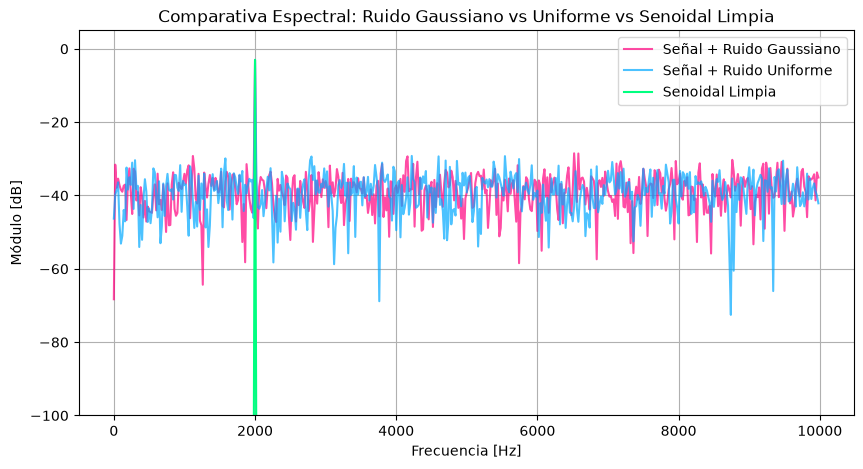

In [103]:
#%% COMPARACIÓN ESPECTRAL: RUIDO GAUSSIANO VS RUIDO UNIFORME
plt.figure(figsize=(10, 5))
plt.plot(ff_vector_pos, salida_g_dB, label='Señal + Ruido Gaussiano', color='#FF007F', alpha=0.7)
plt.plot(ff_vector_pos, salida_u_dB, label='Señal + Ruido Uniforme', color='#00A8FF', alpha=0.7)
plt.plot(ff_vector_pos, salida1_dB, label='Senoidal Limpia', color='#00FF80', linewidth=1.5)

plt.title('Comparativa Espectral: Ruido Gaussiano vs Uniforme vs Senoidal Limpia')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 5)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ Sin embargo, si analizamos el dominio frecuencial, podemos determinar que ambas señales presentan exactamente el mismo pico sintonizado en $2 \text{ kHz}$, la frecuencia de la senoidal, y un ruido blanco idéntico y parejo en el resto de las frecuencias. Esto permite demostrar que señales temporales con formas de onda y estadísticas totalmente diferentes pueden poseer idéntica potencia promedio y distribución de energía en el dominio frecuencial, no resultan mutuamente excluyentes.

<h4><font color='#666B88'> Pulso rectangular (cuadrada):$f = 2 \text{ kHz}$, potencia $P = 1 \text{ W}$ y D = 50% </font></h4>

In [104]:
#%% INCISO 5
xx3 = 1.0 * sig.square(2 * np.pi * ff * tt, duty=0.5)

# <================= FFT =================>
salida3 = np.fft.fft(xx3)[:N//2] / N 
salida3_abs = np.absolute(salida3)
salida3_dB = 10 * np.log10(2 * (salida3_abs**2) + 1e-12)

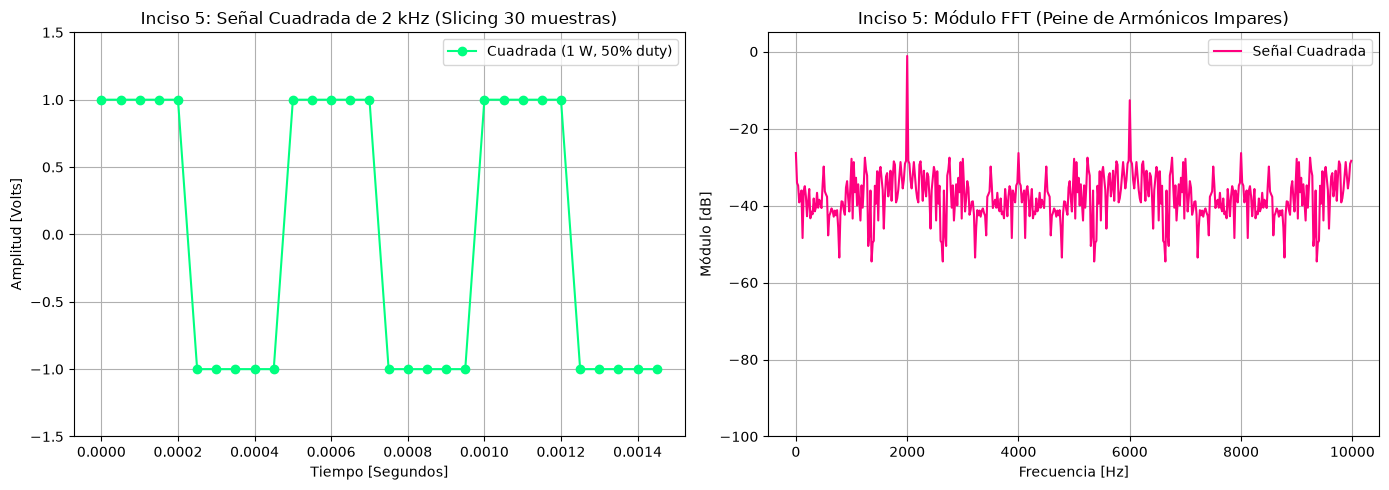

In [105]:
plt.figure(figsize=(14, 5))

# Gráfico izq.: tiempo (slicing 30 muestras)
plt.subplot(1, 2, 1)
plt.plot(tt[:30], xx3[:30], '-o', label='Cuadrada (1 W, 50% duty)', color='#00FF80')
plt.title('Inciso 5: Señal Cuadrada de 2 kHz (Slicing 30 muestras)')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.ylim(-1.5, 1.5)
plt.legend(loc='upper right')
plt.grid(True)

# Gráfico der.: frecuencia (armónicos impares)
plt.subplot(1, 2, 2)
plt.plot(ff_vector_pos, salida3_dB, label='Señal Cuadrada', color='#FF007F')
plt.title('Inciso 5: Módulo FFT (Peine de Armónicos Impares)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 5)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>

$\quad$ Tal como se estableció en la introducción, es posible observar un "peine" de armónicos impares muy definidos ($2 \text{ kHz}, 6 \text{ kHz}, 10 \text{ kHz}, \dots$) en el dominio frecuencial cuya potencia decrece a razón de $1/f$. Teóricamente, esto se explica por el hecho de que la simetría de media onda en el tiempo (izquierda) provoca una cancelación destructiva total que anula por completo todos los armónicos pares del espectro ($4 \text{ kHz}, 8 \text{ kHz}, \dots$), donde solo es posible vizualizar franjas de ruido numérico.

<h3><font color='#69ADFF'>BONUS: SEÑAL EXTRA</font></h3>

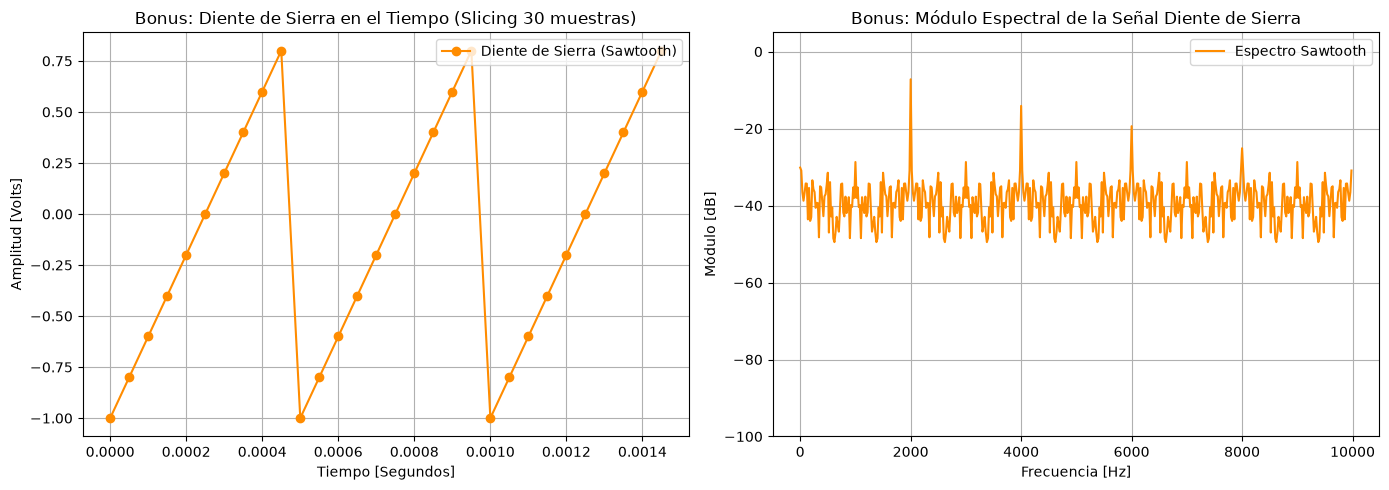

In [106]:
#%% BONUS: SEÑAL DIENTE DE SIERRA (SAWTOOTH)
xx_saw = 1.0 * sig.sawtooth(2 * np.pi * ff * tt)

salida_saw = np.fft.fft(xx_saw)[:N//2] / N
salida_saw_abs = np.abs(salida_saw)
salida_saw_dB = 10 * np.log10(2 * (salida_saw_abs**2) + 1e-12)

plt.figure(figsize=(14, 5))

# Gráfico izq.: tiempo (slicing 30 muestras)
plt.subplot(1, 2, 1)
plt.plot(tt[:30], xx_saw[:30], '-o', label='Diente de Sierra (Sawtooth)', color='#FF8C00')
plt.title('Bonus: Diente de Sierra en el Tiempo (Slicing 30 muestras)')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.legend(loc='upper right')
plt.grid(True)

# Gráfico der.: frecuencia (todos los armónicos)
plt.subplot(1, 2, 2)
plt.plot(ff_vector_pos, salida_saw_dB, label='Espectro Sawtooth', color='#FF8C00')
plt.title('Bonus: Módulo Espectral de la Señal Diente de Sierra')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.ylim(-100, 5)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

<h4><font color='orchid'><b>Análisis:</b></font></h4>


$\quad$ A diferencia de la señal rectangular simétrica, la señal diente de sierra (izquierda) no posee simetría de media onda en el tiempo. Como consecuencia directa en el dominio frecuencial (derecha), el espectro no presenta cancelaciones destructivas por lo que el "peine" armónico continuo que se observa contiene a todas las componentes de frecuencia, tanto pares como impares ($2 \text{ kHz}, 4 \text{ kHz}, 6 \text{ kHz}, 8 \text{ kHz}, \dots$), los cuales decaen de forma progresiva a medida que nos alejamos de la frecuencia fundamental.

## Conclusión



Con el desarrollo de este trabajo fue posible:

$\quad$ En primer lugar, al trabajar con una frecuencia de muestreo de $20 \text{ kHz}$ frente a una señal de $2 \text{ kHz}$, comprobar que se cumple el **Criterio de Nyquist** (garantizando exactamente 10 muestras por período) para evitar el solapamiento de réplicas o *aliasing*. Asimismo, fue posible comprender tanto la ausencia de **Fuga Espectral** (*spectral leakage*) en este ensayo, como las condiciones que provocarían su aparición, debido a la coincidencia de la frecuencia con un bin entero de la grilla ($k = 100$, dada la resolución espectral de $\Delta f = 20 \text{ Hz}$). Esto nos permitió concentrar toda la energía en una única delta limpia y validar de forma directa el Teorema de Parseval de conservación de la energía.

$\quad$ Por otro lado, el agregado de secuencias aleatorias de ruido demostró la potencia del análisis en frecuencia para identificar patrones ocultos en el tiempo. Aunque en el dominio temporal el ruido uniforme y el Gaussiano presentan comportamientos estadísticos disímiles (el primero rígidamente encajonado dentro de una amplitud máxima de $\pm 0.547 \text{ V}$ y el segundo con picos libres en su campana de probabilidad), la FFT nos dejó ver que los espectros de ambos se asemejan: con una idéntica potencia media ($0.1 \text{ W}$), ambos ruidos elevaron el piso del espectro de manera equivalente bajo un comportamiento de ruido blanco, sin llegar a enmascarar la componente del tono fundamental.

$\quad$ Finalmente, el estudio de las señales complejas evidenció de qué manera la geometría de la onda en el tiempo dicta la distribución de energía en la frecuencia. Al analizar la señal cuadrada con un ciclo de actividad del $50\%$, pudimos verificar que su simetría de media onda en el tiempo provoca cancelaciones destructivas que anulan por completo todas las componentes armónicas pares del espectro. De este modo, la potencia se distribuye únicamente en un peine de armónicos impares ($2 \text{ kHz}, 6 \text{ kHz}, 10 \text{ kHz}, \dots$) que decae a razón de $1/f$. Este comportamiento contrasta de forma directa con la señal diente de sierra, cuya asimetría temporal impide la cancelación de componentes, generando un espectro que contiene tanto armónicos pares como impares. En conjunto, estos ensayos consolidan la importancia de comprender la FFT no solo como una herramienta de visualización matemática, sino como el puente físico indispensable entre el diseño teórico y el procesamiento real de señales en sistemas digitales.

## Bibliografía
> Holton, T. (2021). Digital Signal Processing: Principles and Applications. Cambridge University Press.<br>
> Lyons, R. G. (2011). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.<br>
> Downey, A. B. (2016). Think DSP: Digital Signal Processing in Python. O'Reilly Media.<br>
> Porat, B. (1997). A Course in Digital Signal Processing. John Wiley & Sons.<br>
> Hayes, M. H. (1996). Statistical Digital Signal Processing and Modeling. John Wiley & Sons.